
# Tutorial 8 — **Selección y evaluación de modelos** (Regresión y Clasificación)


**Objetivo**: Resolver **un problema de regresión** y **otro de clasificación** definiendo **varios modelos**, evaluando con **métricas apropiadas**, usando **visualizaciones** y **escogiendo el mejor**. Además, verás ejemplos de **underfitting** y **overfitting**.




<a id="material"></a>
## 1) Material de estudio



<a id="flujo"></a>
### 1.1 Flujo general de entrenamiento y evaluación

1) **Dividir** datos en entrenamiento/prueba para medir generalización.  
2) **Ajustar** varios modelos y configurar hiperparámetros.  
3) **Evaluar** con **métricas adecuadas** al tipo de problema.  
4) **Visualizar** resultados (predicciones vs reales, curvas ROC, matrices de confusión, curvas de validación).  
5) **Escoger** el mejor modelo equilibrando desempeño y simplicidad.



<a id="metricas"></a>
### 1.2 Métricas

- **Regresión**: `R²` (entre 0 y 1, más alto mejor), `MAE` y `RMSE` (más bajo mejor).  
- **Clasificación**: `accuracy`, `precision`, `recall`, `f1`, **matriz de confusión**, `ROC-AUC`.



<a id="visualizaciones"></a>
### 1.3 Visualizaciones útiles

- **Regresión**: gráfico de **y_real vs y_pred** (idealmente alineado a la línea `y=x`), **histograma de residuales**, barras comparando métricas entre modelos.  
- **Clasificación**: **matriz de confusión**, **curva ROC** (área bajo la curva), barras de F1/accuracy, **curvas de validación** para ver under/overfitting.



<a id="ejemplos"></a>
## 2) Ejemplos guiados



<a id="regresion"></a>
### 2.1 Comparación de **modelos de regresión**

Usaremos un conjunto **sintético** para reproducir resultados. Probamos **tres** modelos:
- `LinearRegression` (base)
- `Ridge` (regularización L2)
- `RandomForestRegressor` (no lineal)

Evaluaremos **R²**, **MAE** y **RMSE** en *train* y *test*, y elegiremos el mejor por R² en *test*.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor


In [2]:

# 1) Datos sintéticos de REGRESIÓN
rng = np.random.default_rng(42)
X, y = make_regression(n_samples=500, n_features=8, n_informative=6, noise=15.0, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

print("Conjunto de REGRESIÓN creado.")
print(" - Train:", X_tr.shape, "| Test:", X_te.shape)

# 2) Modelos a comparar
modelos_reg = {
    "LinearRegression": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Ridge(alpha=1.0)": Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))]),
    "RandomForest": RandomForestRegressor(n_estimators=250, random_state=42)
}

# 3) Entrenar y evaluar
resultados = []
for nombre, modelo in modelos_reg.items():
    modelo.fit(X_tr, y_tr)
    pred_tr = modelo.predict(X_tr)
    pred_te = modelo.predict(X_te)

    r2_tr = r2_score(y_tr, pred_tr)
    r2_te = r2_score(y_te, pred_te)
    mae_te = mean_absolute_error(y_te, pred_te)
    mse_te = mean_squared_error(y_te, pred_te)
    rmse_te = np.sqrt(mse_te)

    resultados.append([nombre, r2_tr, r2_te, mae_te, rmse_te])

df_reg = pd.DataFrame(resultados, columns=["modelo","R2_train","R2_test","MAE_test","RMSE_test"]).sort_values("R2_test", ascending=False)
print("\nResultados de REGRESIÓN (ordenado por R2_test):")
print(df_reg)

Conjunto de REGRESIÓN creado.
 - Train: (400, 8) | Test: (100, 8)

Resultados de REGRESIÓN (ordenado por R2_test):
             modelo  R2_train   R2_test   MAE_test  RMSE_test
1  Ridge(alpha=1.0)  0.987663  0.987636  12.912984  15.813272
0  LinearRegression  0.987669  0.987572  12.935485  15.854474
2      RandomForest  0.979444  0.887463  36.496460  47.708245


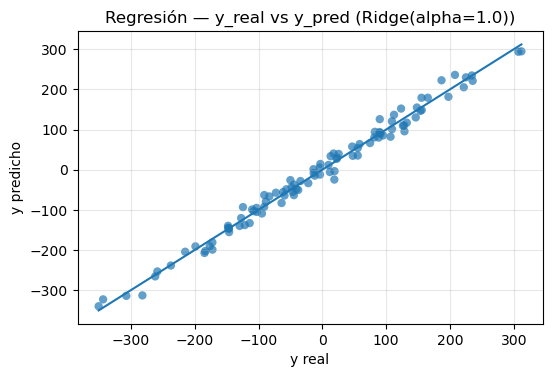

In [3]:

# 4) Visualizaciones clave (una por figura)
best_name = df_reg.iloc[0]["modelo"]
best_model = modelos_reg[best_name]
y_pred_best = best_model.predict(X_te)

# y_real vs y_pred
plt.figure(figsize=(6,3.8))
plt.scatter(y_te, y_pred_best, alpha=0.7, edgecolor="none")
minv, maxv = np.min([y_te, y_pred_best]), np.max([y_te, y_pred_best])
plt.plot([minv, maxv], [minv, maxv])
plt.title(f"Regresión — y_real vs y_pred ({best_name})")
plt.xlabel("y real"); plt.ylabel("y predicho")
plt.grid(True, alpha=0.3)
plt.show()


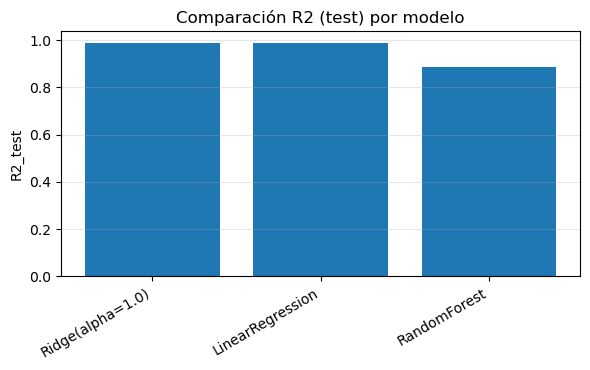

In [4]:
# Barras: R2_test por modelo
plt.figure(figsize=(6,3.8))
plt.bar(df_reg["modelo"], df_reg["R2_test"])
plt.title("Comparación R2 (test) por modelo")
plt.ylabel("R2_test")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


<a id="clasificacion"></a>
### 2.2 Comparación de **modelos de clasificación**

Generamos un conjunto **sintético** y comparamos:
- `LogisticRegression` (base lineal)
- `KNeighborsClassifier` (no paramétrico)
- `RandomForestClassifier` (ensamble)

Métricas reportadas en *test*: **accuracy**, **precision**, **recall**, **f1**, **ROC‑AUC**. Además visualizamos **matriz de confusión** (modelo ganador) y **curva ROC** (todos).


In [5]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [6]:
# 1) Datos sintéticos de CLASIFICACIÓN
X, y = make_classification(n_samples=600, n_features=12, n_informative=6, n_redundant=2,
                           class_sep=1.5, weights=[0.6, 0.4], random_state=0)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

print("Conjunto de CLASIFICACIÓN creado.")
print(" - Train:", X_tr.shape, "| Test:", X_te.shape, "| Proporción clase 1 (test):", round(y_te.mean(), 3))

# 2) Modelos
modelos_clf = {
    "LogReg": Pipeline([("scaler", StandardScaler()), ("logreg", LogisticRegression(max_iter=1000))]),
    "KNN(k=7)": Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=7))]),
    "RandomForest": RandomForestClassifier(n_estimators=250, random_state=0)
}

# 3) Entrenar y evaluar
rows = []
probas = {}
for nombre, modelo in modelos_clf.items():
    modelo.fit(X_tr, y_tr)
    yp = modelo.predict(X_te)
    # intentar obtener proba para ROC
    if hasattr(modelo, "predict_proba"):
        prob = modelo.predict_proba(X_te)[:,1]
    else:
        # fallback: usar decision_function si existe
        if hasattr(modelo, "decision_function"):
            from sklearn.preprocessing import MinMaxScaler
            scores = modelo.decision_function(X_te).reshape(-1,1)
            prob = MinMaxScaler().fit_transform(scores).ravel()
        else:
            prob = None

    acc = accuracy_score(y_te, yp)
    pre = precision_score(y_te, yp, zero_division=0)
    rec = recall_score(y_te, yp, zero_division=0)
    f1  = f1_score(y_te, yp, zero_division=0)
    roc = roc_auc_score(y_te, prob) if prob is not None else np.nan

    rows.append([nombre, acc, pre, rec, f1, roc])
    probas[nombre] = prob

df_clf = pd.DataFrame(rows, columns=["modelo","accuracy","precision","recall","f1","roc_auc"]).sort_values("f1", ascending=False)
print("\nResultados de CLASIFICACIÓN (ordenado por F1):")
print(df_clf)

Conjunto de CLASIFICACIÓN creado.
 - Train: (450, 12) | Test: (150, 12) | Proporción clase 1 (test): 0.407

Resultados de CLASIFICACIÓN (ordenado por F1):
         modelo  accuracy  precision    recall        f1   roc_auc
1      KNN(k=7)  0.913333   0.928571  0.852459  0.888889  0.951372
2  RandomForest  0.900000   0.870968  0.885246  0.878049  0.961871
0        LogReg  0.840000   0.824561  0.770492  0.796610  0.912323


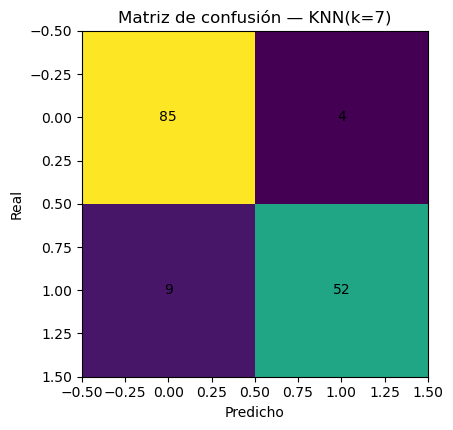

In [7]:

best_name = df_clf.iloc[0]["modelo"]
best_model = modelos_clf[best_name]
yp_best = best_model.predict(X_te)

# 1) Matriz de confusión del mejor
cm = confusion_matrix(y_te, yp_best)
plt.figure(figsize=(5.2,4.4))
plt.imshow(cm)
plt.title(f"Matriz de confusión — {best_name}")
plt.xlabel("Predicho"); plt.ylabel("Real")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()



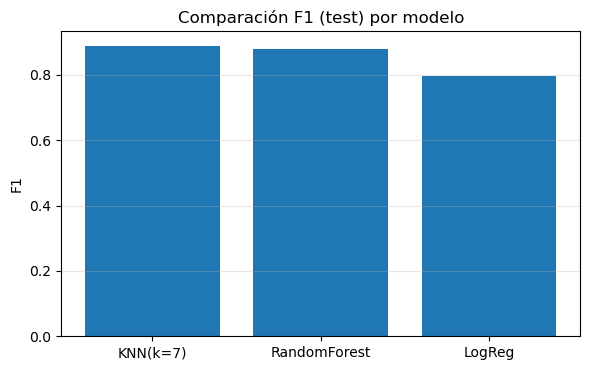

In [8]:
# 3) Barras de F1 por modelo
plt.figure(figsize=(6,3.8))
plt.bar(df_clf["modelo"], df_clf["f1"])
plt.title("Comparación F1 (test) por modelo")
plt.ylabel("F1")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


<a id="under-over"></a>
### 2.3 Underfitting y Overfitting (validación por complejidad)

- **Regresión (polinomios)**: variamos el **grado** y observamos **RMSE** en *train/test*.  
- **Clasificación (KNN)**: variamos **k** y observamos *accuracy* en *train/test*.

La brecha grande entre *train* (muy bueno) y *test* (malo) sugiere **overfitting**. Mal desempeño en ambos sugiere **underfitting**.


In [9]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


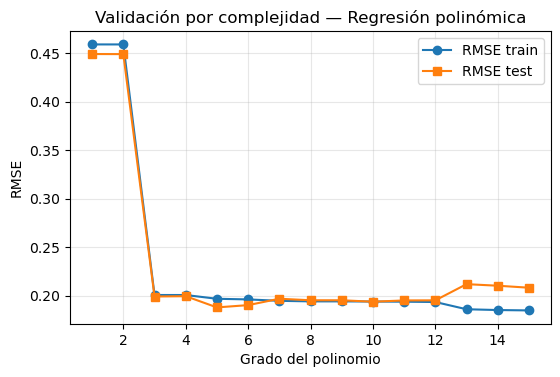

In [10]:

# --- REGRESIÓN: función no lineal y = sin(x) + ruido ---
rng = np.random.default_rng(1)
X = rng.uniform(-3, 3, size=300).reshape(-1, 1)
y = np.sin(X).ravel() + rng.normal(0, 0.2, size=X.shape[0])

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=0)

grados = list(range(1, 16))
rmse_tr, rmse_te = [], []

for d in grados:
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("scaler", StandardScaler()),
        ("lr", LinearRegression())
    ])
    pipe.fit(X_tr, y_tr)
    p_tr = pipe.predict(X_tr)
    p_te = pipe.predict(X_te)
    rmse_tr.append(np.sqrt(mean_squared_error(y_tr, p_tr)))
    rmse_te.append(np.sqrt(mean_squared_error(y_te, p_te)))

plt.figure(figsize=(6.2,3.8))
plt.plot(grados, rmse_tr, marker="o", label="RMSE train")
plt.plot(grados, rmse_te, marker="s", label="RMSE test")
plt.title("Validación por complejidad — Regresión polinómica")
plt.xlabel("Grado del polinomio"); plt.ylabel("RMSE")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()


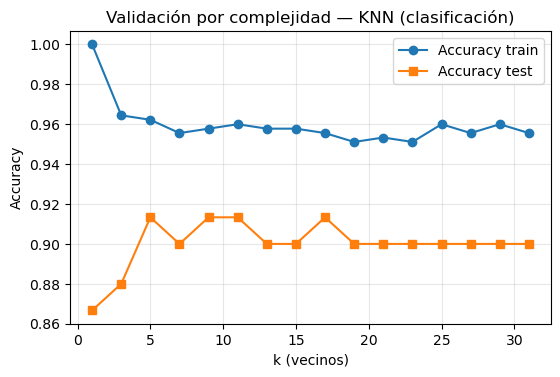

In [11]:

# --- CLASIFICACIÓN: KNN variando k ---
from sklearn.datasets import make_moons
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X, y = make_moons(n_samples=600, noise=0.25, random_state=0)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

k_vals = list(range(1, 32, 2))
acc_tr, acc_te = [], []

for k in k_vals:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_tr, y_tr)
    acc_tr.append(accuracy_score(y_tr, clf.predict(X_tr)))
    acc_te.append(accuracy_score(y_te, clf.predict(X_te)))

plt.figure(figsize=(6.2,3.8))
plt.plot(k_vals, acc_tr, marker="o", label="Accuracy train")
plt.plot(k_vals, acc_te, marker="s", label="Accuracy test")
plt.title("Validación por complejidad — KNN (clasificación)")
plt.xlabel("k (vecinos)"); plt.ylabel("Accuracy")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()


<a id="ejercicios"></a>
## 3) Ejercicios

> **Formato**: agrega `print(...)` **descriptivos** y figuras con títulos/ejes/leyendas.




### Ejercicio 1 — Regresión (ampliación de modelos)
1. Agrega **`Lasso`** y **`SVR` (kernel RBF)** a la comparación de regresión.  
2. Reporta `R²`, `MAE`, `RMSE` en *test* y actualiza el gráfico de barras.  
3. Muestra **residuales** vs **y_pred** para el mejor modelo.



### Ejercicio 2 — Clasificación (métricas adicionales)
1. Agrega **`SVC` (kernel RBF)** con `probability=True`.  
2. Reporta además **ROC‑AUC** y **PR‑AUC**.  
3. Grafica la **curva Precision‑Recall** y una **matriz de confusión normalizada** del mejor modelo.



### Ejercicio 3 — Curvas de validación / aprendizaje
1. Para **KNN**, grafica *train/test* vs `k = 1..25` (paso 2) e interpreta **under/overfitting**.  
2. (Opcional) Usa `learning_curve` para ver cómo evolucionan los *scores* al variar el tamaño de entrenamiento.



### Ejercicio 4 — Criterio de selección
Define un **criterio de selección** (por ejemplo: “R² alto y RMSE bajo” en regresión; “F1 y ROC‑AUC altos” en clasificación). **Escoge** el modelo final y justifica en 2–3 líneas.